In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 1) 깔려있던 걸 지우고
!pip -q uninstall -y transformers accelerate tokenizers huggingface_hub

# 2) 호환되는 세트로 재설치
#  - 이 조합은 PyTorch 2.x + Python 3.12에서 잘 맞습니다.
!pip -q install --upgrade \
  "transformers>=4.44,<5" \
  "accelerate>=0.33" \
  "tokenizers>=0.20" \
  "huggingface_hub>=0.24" \
  "safetensors>=0.4.2" \
  "protobuf<5"  # 드물게 생기는 protobuf 충돌 예방

# 3) 버전 확인
import importlib, pkgutil, sys
import transformers, accelerate, tokenizers, huggingface_hub, safetensors
print("transformers:", transformers.__version__)
print("accelerate  :", accelerate.__version__)
print("tokenizers  :", tokenizers.__version__)
print("hub         :", huggingface_hub.__version__)

# 4) 런타임 재시작 안내
import os, IPython
print("\n✅ 설치 완료. 이제 '런타임 > 런타임 다시 시작'을 눌러주세요.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 22.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
transformers: 4.57.0
accelerate 

In [2]:
import os, re, json, unicodedata, random, math, time
import numpy as np
import pandas as pd
from typing import List, Dict
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

In [3]:
# =========================
# 0) 경로/하이퍼파라미터 설정
# =========================
FILE1 = "/content/drive/MyDrive/중간평가_이후_모델/all_preprocessed.csv"   # (text,label) 0/1 섞임
FILE2 = "/content/drive/MyDrive/중간평가_이후_모델/merged_dialogues.csv"  # (label,text) or (text,label) 일반 0만
LEXICON_PATH = "/content/drive/MyDrive/중간평가_이후_모델/lexicon_artifacts/LEXICON_topK_logodds.json"

MODEL_NAME   = "skt/kobert-base-v1"
OUTPUT_DIR   = "/content/drive/MyDrive/중간평가_이후_모델/models/kobert_with_lexicon"
MAX_LEN      = 256
EPOCHS       = 3
BATCH_SIZE   = 32
EVAL_BS      = 64
LR           = 5e-5
W_DECAY      = 0.01
WARMUP_STEPS = 0
DROPOUT      = 0.1
SEED         = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [4]:
# =========================
# 1) 데이터 로드 & 컬럼 정리
# =========================
def read_csv_flex(path):
    df = pd.read_csv(path)
    # 가장 흔한 2컬럼 케이스 대응
    if {"text","label"}.issubset(df.columns):
        return df[["text","label"]].copy()
    # 첫 두 컬럼만 쓰되, 제목 추정
    df2 = df.iloc[:, :2].copy()
    # 첫 파일은 보통 (text,label)
    # 두 번째 파일은 보통 (label,text) → label이 0만
    # 안전하게: 숫자 비율 높은 컬럼을 label로 가정
    c0_num = pd.to_numeric(df2.iloc[:,0], errors="coerce").notna().mean()
    c1_num = pd.to_numeric(df2.iloc[:,1], errors="coerce").notna().mean()
    if c0_num > c1_num:
        df2.columns = ["label","text"]
    else:
        df2.columns = ["text","label"]
    return df2[["text","label"]]

mixed = read_csv_flex(FILE1)
daily = read_csv_flex(FILE2)

# 타입 캐스팅/정리
mixed = mixed.dropna().reset_index(drop=True)
daily = daily.dropna().reset_index(drop=True)
mixed["text"] = mixed["text"].astype(str)
daily["text"] = daily["text"].astype(str)
mixed["label"] = mixed["label"].astype(int)
daily["label"] = daily["label"].astype(int)

print("mixed shape:", mixed.shape, "daily shape:", daily.shape)
print("mixed labels:", mixed["label"].value_counts().to_dict())
print("daily labels:", daily["label"].value_counts().to_dict())

mixed shape: (1840, 2) daily shape: (728257, 2)
mixed labels: {1: 1515, 0: 325}
daily labels: {0: 728257}


In [5]:
# =========================
# 2) 균형 샘플링 (pos = mixed 1, neg = daily 0)
# =========================
pos_df = mixed[mixed["label"] == 1].copy()
neg_pool = daily[daily["label"] == 0].copy()
n_pos = len(pos_df)
neg_sample = neg_pool.sample(n=n_pos, random_state=SEED, replace=False)

balanced = pd.concat(
    [pos_df[["text","label"]], neg_sample[["text","label"]]],
    axis=0, ignore_index=True
).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    balanced, test_size=0.2, random_state=SEED, stratify=balanced["label"]
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"]
)

print(f"[Split] train={len(train_df)}, valid={len(valid_df)}, test={len(test_df)}")

[Split] train=2424, valid=303, test=303


In [6]:
# =========================
# 3) LEXICON 로드 & 피처 추출
# =========================
with open(LEXICON_PATH, "r", encoding="utf-8") as f:
    LEXICON = json.load(f)
LEX_TERMS = list(LEXICON.keys())

def _norm(s: str) -> str:
    s = unicodedata.normalize("NFKC", str(s)).strip()
    s = s.replace("계 좌", "계좌").replace("계.좌", "계좌").replace("앱  설치", "앱 설치")
    return s

def extract_features_single(text: str):
    t = _norm(text)
    hits = [1.0 if term in t else 0.0 for term in LEX_TERMS]
    total_w = sum(float(LEXICON[term]) for term, h in zip(LEX_TERMS, hits) if h)
    return np.array(hits + [total_w], dtype=np.float32)  # [F_bin + 1]

# 표준화 통계 (train only)
feat_mat_train = np.stack([extract_features_single(s) for s in train_df["text"].astype(str)], axis=0)
feat_mean = feat_mat_train.mean(axis=0)
feat_std  = feat_mat_train.std(axis=0) + 1e-6

def featurize_batch(text_list: List[str]):
    M = np.stack([extract_features_single(s) for s in map(str, text_list)], axis=0)
    M = (M - feat_mean) / feat_std
    return torch.tensor(M, dtype=torch.float32)

In [7]:
# =========================
# 4) 토크나이저 & 샘플 인코딩
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = 0

def encode_frame(df_):
    enc = tokenizer(df_["text"].tolist(), truncation=True, padding=False, max_length=MAX_LEN)
    samples = []
    for i in range(len(df_)):
        input_ids = enc["input_ids"][i]
        samples.append({
            "input_ids": input_ids,
            "text": df_["text"].iloc[i],
            "label": int(df_["label"].iloc[i])
        })
    return samples

train_samples = encode_frame(train_df)
valid_samples = encode_frame(valid_df)
test_samples  = encode_frame(test_df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

In [8]:
# =========================
# 5) Collate (패딩 + feat_vec)
# =========================
@dataclass
class CollateCtx:
    pad_id: int

ctx = CollateCtx(pad_id=tokenizer.pad_token_id)

def custom_collate_fn(samples):
    max_len = max(len(s["input_ids"]) for s in samples)
    input_ids = [s["input_ids"] + [ctx.pad_id]*(max_len - len(s["input_ids"])) for s in samples]
    attention_mask = [[1]*len(s["input_ids"]) + [0]*(max_len - len(s["input_ids"])) for s in samples]
    labels = [s["label"] for s in samples]
    texts  = [s["text"]  for s in samples]

    feat_vec = featurize_batch(texts)  # [B, F]

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
        "feat_vec": feat_vec,
        "text": texts
    }

train_loader = DataLoader(train_samples, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=custom_collate_fn)
valid_loader = DataLoader(valid_samples, batch_size=EVAL_BS,  shuffle=False, collate_fn=custom_collate_fn)
test_loader  = DataLoader(test_samples,  batch_size=EVAL_BS,  shuffle=False, collate_fn=custom_collate_fn)

In [9]:
# =========================
# 6) 모델 정의 (KoBERT + Lexicon concat)
# =========================
class KoBERTWithLexicon(nn.Module):
    def __init__(self, model_name: str, num_feats: int, num_labels: int = 2, dropout: float = 0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden + num_feats, num_labels)

    def forward(self, input_ids, attention_mask, feat_vec, labels=None):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]  # [B, H]
        x = torch.cat([cls, feat_vec], dim=1)  # [B, H+F]
        x = self.dropout(x)
        logits = self.classifier(x)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}

num_feats = len(LEX_TERMS) + 1
model = KoBERTWithLexicon(MODEL_NAME, num_feats=num_feats, num_labels=2, dropout=DROPOUT).to(device)

config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

In [10]:
# =========================
# 7) 학습 설정
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=W_DECAY)
num_training_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=num_training_steps)



In [13]:
# =========================
# 8) 학습 루프 (valid F1 모니터링, best 저장)
#   - ✅ feat_mean/std는 .npy로 분리 저장
#   - ✅ ckpt에는 numpy를 넣지 않음 (PyTorch 2.6 weights_only 기본과 호환)
# =========================
best_f1, best_path = -1.0, os.path.join(OUTPUT_DIR, "best.pt")

# feat 통계는 학습 시작 전에 한 번 저장(선택) — 베스트 갱신 시점에 저장해도 OK
np.save(os.path.join(OUTPUT_DIR, "feat_mean.npy"), feat_mean)
np.save(os.path.join(OUTPUT_DIR, "feat_std.npy"),  feat_std)

print("\n🚀 Training...")
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in batch.items()}
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            feat_vec=batch["feat_vec"],
            labels=batch["labels"]
        )
        loss = out["loss"]
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ─ Validation ─
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for eb in valid_loader:
            eb = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in eb.items()}
            out = model(
                input_ids=eb["input_ids"],
                attention_mask=eb["attention_mask"],
                feat_vec=eb["feat_vec"],
                labels=eb["labels"]
            )
            preds = out["logits"].argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(eb["labels"].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    print(f"✅ Epoch {epoch}: train_loss={total_loss/len(train_loader):.4f} | valid Acc={acc:.4f} F1={f1:.4f}")

    # ─ Best 저장 (numpy 제외) ─
    if f1 > best_f1:
        best_f1 = f1
        torch.save({
            "state_dict": model.state_dict(),
            "model_name": MODEL_NAME,
            "num_feats": num_feats,
            "lexicon_path": LEXICON_PATH
        }, best_path)
        # feat_mean/std는 이미 .npy로 저장되어 있으므로 재사용 가능
        print(f"  ↳ ✅ Best updated. F1={best_f1:.4f} → {best_path}")



🚀 Training...


Epoch 1/3:   0%|          | 0/76 [00:00<?, ?it/s]

✅ Epoch 1: train_loss=0.3210 | valid Acc=0.8317 F1=0.8421
  ↳ ✅ Best updated. F1=0.8421 → /content/drive/MyDrive/중간평가_이후_모델/models/kobert_with_lexicon/best.pt


Epoch 2/3:   0%|          | 0/76 [00:00<?, ?it/s]

✅ Epoch 2: train_loss=0.3221 | valid Acc=0.8317 F1=0.8421


Epoch 3/3:   0%|          | 0/76 [00:00<?, ?it/s]

✅ Epoch 3: train_loss=0.3257 | valid Acc=0.8317 F1=0.8421


In [14]:

# =========================
# 9) 테스트 평가 (best ckpt 로드)
#   ✅ numpy 분리 저장 방식 대응
# =========================
# feat_mean / feat_std 다시 로드 (학습 시 저장된 npy)
feat_mean = np.load(os.path.join(OUTPUT_DIR, "feat_mean.npy"))
feat_std  = np.load(os.path.join(OUTPUT_DIR, "feat_std.npy"))

# 체크포인트 로드 (PyTorch 2.6+ safe 모드 기본 OK)
ckpt = torch.load(best_path, map_location="cpu")  # weights_only=True 기본
model = KoBERTWithLexicon(
    ckpt["model_name"], num_feats=ckpt["num_feats"], num_labels=2, dropout=DROPOUT
)
model.load_state_dict(ckpt["state_dict"])
model.to(device).eval()

# ─ 테스트셋 평가 ─
all_preds, all_labels = [], []
with torch.no_grad():
    for eb in test_loader:
        eb = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in eb.items()}
        out = model(
            input_ids=eb["input_ids"],
            attention_mask=eb["attention_mask"],
            feat_vec=eb["feat_vec"],
            labels=eb["labels"]
        )
        preds = out["logits"].argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(eb["labels"].cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds)
print(f"\n🏁 Test Result → Acc={test_acc:.4f} | F1={test_f1:.4f}")



🏁 Test Result → Acc=0.7987 | F1=0.8026


In [15]:
# =========================
# 10) 결과 저장 (numpy 분리 저장 포함)
# =========================
# 모델 가중치만 저장
torch.save({
    "state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "num_feats": num_feats,
    "lexicon_path": LEXICON_PATH
}, os.path.join(OUTPUT_DIR, "final.pt"))

# feat_mean/std 이미 npy로 존재 → 그대로 사용
tokenizer.save_pretrained(OUTPUT_DIR)

# 평가 지표 저장
metrics = {
    "test_acc": float(test_acc),
    "test_f1": float(test_f1),
    "best_f1_valid": float(best_f1)
}
with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("\n💾 Saved Artifacts:")
print("  - final.pt (model weights)")
print("  - feat_mean.npy / feat_std.npy (scaler params)")
print("  - metrics.json (evaluation metrics)")
print("  - tokenizer config")
print("📁 Output dir:", OUTPUT_DIR)



💾 Saved Artifacts:
  - final.pt (model weights)
  - feat_mean.npy / feat_std.npy (scaler params)
  - metrics.json (evaluation metrics)
  - tokenizer config
📁 Output dir: /content/drive/MyDrive/중간평가_이후_모델/models/kobert_with_lexicon


== Test @ threshold=0.50 ==
Accuracy : 0.7987
Precision: 0.7848
Recall   : 0.8212
F1       : 0.8026

Confusion Matrix [[TN FP]
                    [FN TP]]:
 [[118  34]
 [ 27 124]]

Classification Report:
               precision    recall  f1-score   support

           0     0.8138    0.7763    0.7946       152
           1     0.7848    0.8212    0.8026       151

    accuracy                         0.7987       303
   macro avg     0.7993    0.7988    0.7986       303
weighted avg     0.7993    0.7987    0.7986       303


AUPRC  : 0.8783
ROC-AUC: 0.8905


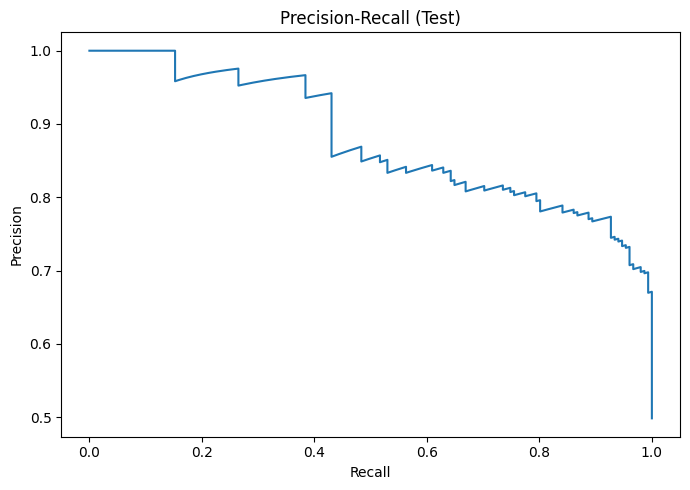

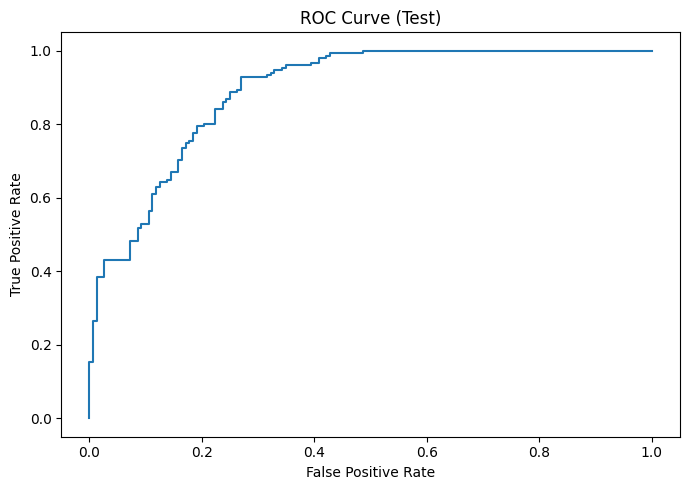


== Tuned threshold for Recall≥0.90 ==
Threshold : 0.3597
Accuracy  : 0.8251
Precision : 0.7692
Recall    : 0.9272
F1        : 0.8408
Confusion Matrix [[TN FP]
                    [FN TP]]:
 [[110  42]
 [ 11 140]]


In [18]:
# -*- coding: utf-8 -*-
import numpy as np, torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, average_precision_score, roc_auc_score
)

# 1) 스케일러/체크포인트 로드 후 모델 준비
feat_mean = np.load(os.path.join(OUTPUT_DIR, "feat_mean.npy"))
feat_std  = np.load(os.path.join(OUTPUT_DIR, "feat_std.npy"))
ckpt = torch.load(best_path, map_location="cpu")  # weights_only=True 기본
model = KoBERTWithLexicon(ckpt["model_name"], num_feats=ckpt["num_feats"], num_labels=2, dropout=DROPOUT).to(device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

# 2) 테스트셋 예측(확률)
all_probs, all_labels = [], []
with torch.no_grad():
    for eb in test_loader:
        eb = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in eb.items()}
        out = model(
            input_ids=eb["input_ids"],
            attention_mask=eb["attention_mask"],
            feat_vec=eb["feat_vec"],
            labels=None
        )
        prob_pos = torch.softmax(out["logits"], dim=-1)[:, 1]
        all_probs.extend(prob_pos.cpu().numpy())
        all_labels.extend(eb["labels"].cpu().numpy())

probs  = np.array(all_probs)
y_true = np.array(all_labels)

# 3) 기본 임계값 0.5 지표 + 컨퓨전 매트릭스
thr = 0.50
y_pred = (probs >= thr).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)

print(f"== Test @ threshold={thr:.2f} ==")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print("\nConfusion Matrix [[TN FP]\n                    [FN TP]]:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4, zero_division=0))

# 4) PR/ROC 커브 & 면적
p, r, th_pr   = precision_recall_curve(y_true, probs)
fpr, tpr, _   = roc_curve(y_true, probs)
auprc  = average_precision_score(y_true, probs)
rocauc = roc_auc_score(y_true, probs)
print(f"\nAUPRC  : {auprc:.4f}")
print(f"ROC-AUC: {rocauc:.4f}")

plt.figure(figsize=(7,5))
plt.plot(r, p)
plt.title("Precision-Recall (Test)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr)
plt.title("ROC Curve (Test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

# 5) 리콜 우선 임계값 튜닝 (예: Recall ≥ 0.90에서 Precision 최대)
target_recall = 0.90
mask = r >= target_recall
if mask.any():
    idxs = np.where(mask)[0]
    idx = idxs[np.argmax(p[mask])]
    tuned_thr = th_pr[idx-1] if idx > 0 and (idx-1) < len(th_pr) else thr
    y_pred_t = (probs >= tuned_thr).astype(int)
    acc_t  = accuracy_score(y_true, y_pred_t)
    prec_t = precision_score(y_true, y_pred_t, zero_division=0)
    rec_t  = recall_score(y_true, y_pred_t, zero_division=0)
    f1_t   = f1_score(y_true, y_pred_t, zero_division=0)
    cm_t   = confusion_matrix(y_true, y_pred_t)

    print(f"\n== Tuned threshold for Recall≥{target_recall:.2f} ==")
    print(f"Threshold : {tuned_thr:.4f}")
    print(f"Accuracy  : {acc_t:.4f}")
    print(f"Precision : {prec_t:.4f}")
    print(f"Recall    : {rec_t:.4f}")
    print(f"F1        : {f1_t:.4f}")
    print("Confusion Matrix [[TN FP]\n                    [FN TP]]:\n", cm_t)
else:
    print(f"\n⚠️ Recall≥{target_recall:.2f} 달성 임계값을 찾지 못했습니다. PR 커브를 참고해 기준을 조정하세요.")
